# Capacity study: does network size move the long-horizon failures?

**Question (George, 2026-07-13).** Every continuous-time result so far — the collapse of the
unweighted loss past one lap, the stalled causal fronts past two — was measured with one
architecture, 4 hidden layers × 50 tanh units. If those failures are symptoms of a too-small
network, all the conclusions change. This study varies **only** capacity and the starting
state: depths $\{2, 4, 6, 8, 10\}$ × widths $\{16, 32, 64, 128, 256\}$ (25 architectures),
both training variants (unweighted, Experiment-A protocol; causal weighting, Experiment-B
protocol), the two first-failure horizons ($T = 14$ for unweighted, $T = 27$ for causal —
both run for both variants), and six starting states — $(2,0)$ plus five Latin-Hypercube
points over the agreed rectangle. 600 runs, one HTCondor job each; budgets, collocation
density and metrics unchanged from the horizon sweeps.

Every run scores against its own freshly integrated order-6 reference (h = 1e-3, scoring
only). Metrics: relative L2 over the trajectory, and the squared relative error normalised
by the modulus of the true state (MSE quoted). This notebook aggregates whatever runs have
finished; re-run it as condor delivers more.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import capacity as cap

FIGURES = Path.cwd() / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})

rows = [json.loads(p.read_text()) for p in sorted(cap.RESULTS.glob("*.json"))]
df = pd.DataFrame([r for r in rows if not r.get("smoke")])
total = (len(cap.VARIANTS) * len(cap.HORIZONS) * len(cap.DEPTHS)
         * len(cap.WIDTHS) * len(cap.starts()))
print(f"{len(df)} of {total} runs completed")
if len(df):
    print(df.groupby(["variant", "horizon"]).size().to_string())

600 of 600 runs completed
variant     horizon
causal      14.0       150
            27.0       150
unweighted  14.0       150
            27.0       150


## Figure 1 — the landscape: error against architecture

Median relative L2 over the available starts, one heatmap per (variant, horizon). If the
long-horizon failures were a capacity problem, error should fall along the diagonal towards
deep-and-wide; a flat wall of order-one error says capacity is not the lever.

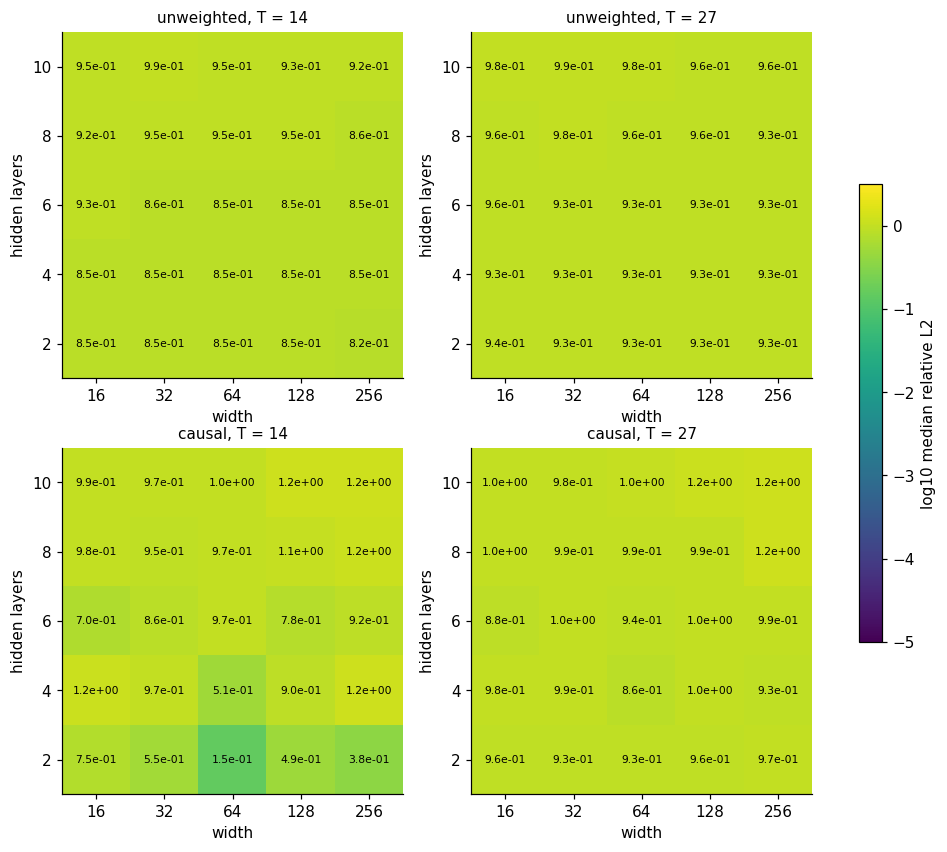

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for i, variant in enumerate(cap.VARIANTS):
    for j, T in enumerate(cap.HORIZONS):
        ax = axes[i, j]
        sub = df[(df.variant == variant) & (df.horizon == T)] if len(df) else df
        grid = np.full((len(cap.DEPTHS), len(cap.WIDTHS)), np.nan)
        if len(sub):
            med = sub.groupby(["depth", "width"]).rel_l2.median()
            for (d, w), v in med.items():
                grid[cap.DEPTHS.index(d), cap.WIDTHS.index(w)] = np.log10(v)
        im = ax.imshow(grid, cmap="viridis", aspect="auto",
                       vmin=-5, vmax=0.5, origin="lower")
        for a in range(len(cap.DEPTHS)):
            for b in range(len(cap.WIDTHS)):
                if np.isfinite(grid[a, b]):
                    ax.text(b, a, f"{10**grid[a,b]:.1e}", ha="center",
                            va="center", fontsize=7,
                            color="w" if grid[a, b] < -2 else "k")
        ax.set_xticks(range(len(cap.WIDTHS)), cap.WIDTHS)
        ax.set_yticks(range(len(cap.DEPTHS)), cap.DEPTHS)
        ax.set_xlabel("width")
        ax.set_ylabel("hidden layers")
        ax.set_title(f"{variant}, T = {T:g}", fontsize=10)
        ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.6, label="log10 median relative L2")
fig.savefig(FIGURES / "01_error_heatmaps.png", bbox_inches="tight")
plt.show()

## Figure 2 — error against width, per depth

The same data as lines: median over starts, one line per depth. Reads the capacity trend
directly and shows whether depth and width trade off or saturate.

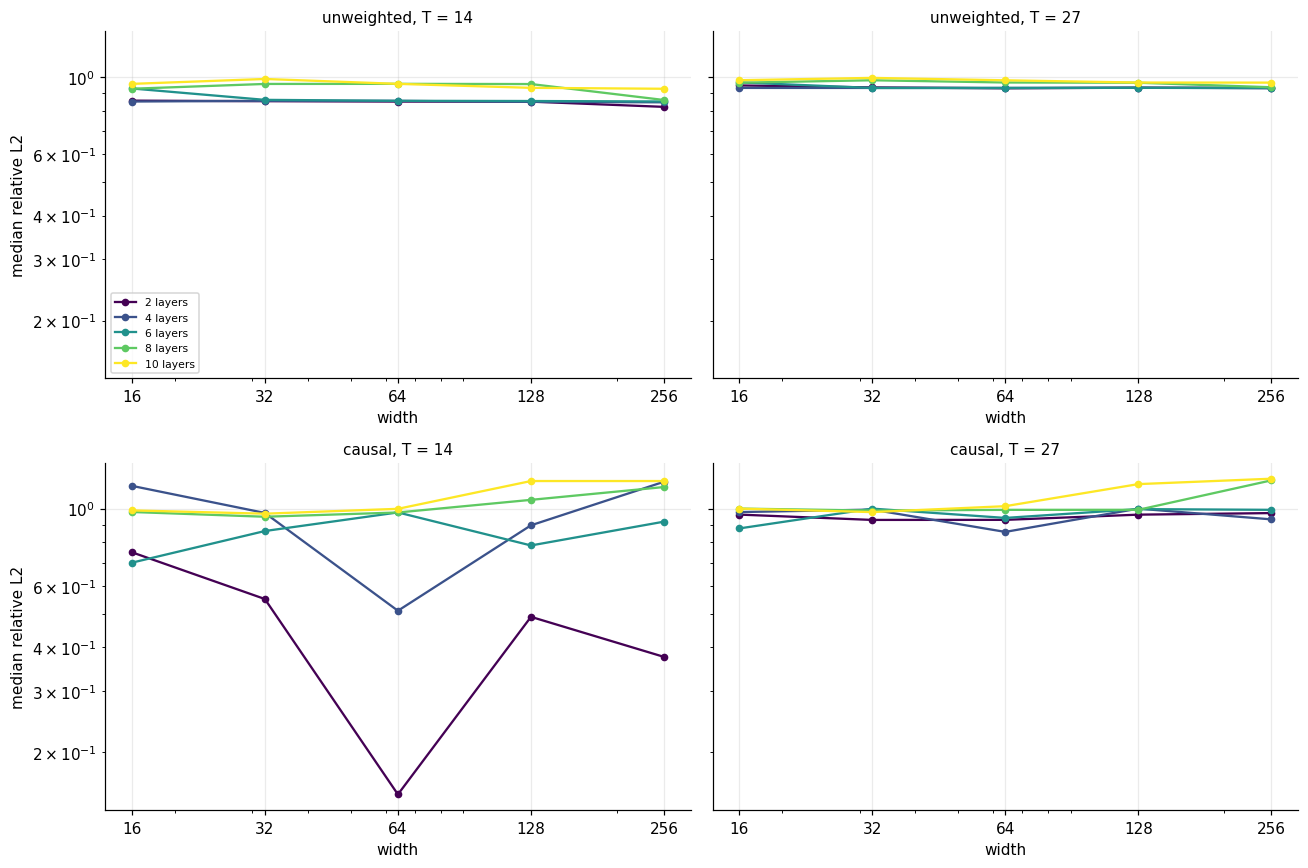

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for i, variant in enumerate(cap.VARIANTS):
    for j, T in enumerate(cap.HORIZONS):
        ax = axes[i, j]
        sub = df[(df.variant == variant) & (df.horizon == T)] if len(df) else df
        cmap = plt.get_cmap("viridis")
        for k, d in enumerate(cap.DEPTHS):
            g = (sub[sub.depth == d].groupby("width").rel_l2.median()
                 if len(sub) else pd.Series(dtype=float))
            if len(g):
                ax.loglog(g.index, g.values, "-o", ms=4,
                          color=cmap(k / (len(cap.DEPTHS) - 1)),
                          label=f"{d} layers")
        ax.set_title(f"{variant}, T = {T:g}", fontsize=10)
        ax.set_xlabel("width")
        ax.set_xticks(cap.WIDTHS, cap.WIDTHS)
axes[0, 0].set_ylabel("median relative L2")
axes[1, 0].set_ylabel("median relative L2")
axes[0, 0].legend(fontsize=7)
fig.tight_layout()
fig.savefig(FIGURES / "02_error_vs_width.png", bbox_inches="tight")
plt.show()

## Figure 3 — error against parameter count, every run

Every completed run as one dot (no medians): parameter count on the x-axis, colour =
variant, marker = horizon. Vertical spread at fixed x is the effect of the starting state
and everything else capacity does not explain.

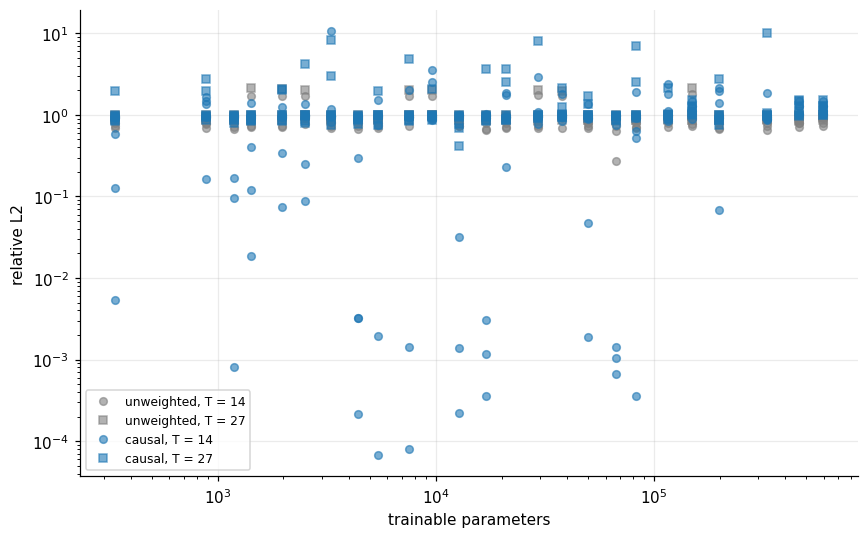

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
if len(df):
    for variant, colour in [("unweighted", "0.5"), ("causal", "C0")]:
        for T, marker in [(14.0, "o"), (27.0, "s")]:
            sub = df[(df.variant == variant) & (df.horizon == T)]
            if len(sub):
                ax.loglog(sub.n_parameters, sub.rel_l2, marker, ms=5,
                          color=colour, alpha=0.6,
                          label=f"{variant}, T = {T:g}")
ax.set_xlabel("trainable parameters")
ax.set_ylabel("relative L2")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "03_error_vs_parameters.png", bbox_inches="tight")
plt.show()

## Figure 4 — the causal front against capacity

Median final awake fraction of the causal runs (left: T = 14, right: T = 27). If bigger
networks let the front cross faster, the T = 27 map should brighten towards large
architectures; if the stall is architecture-independent, it stays dark everywhere.

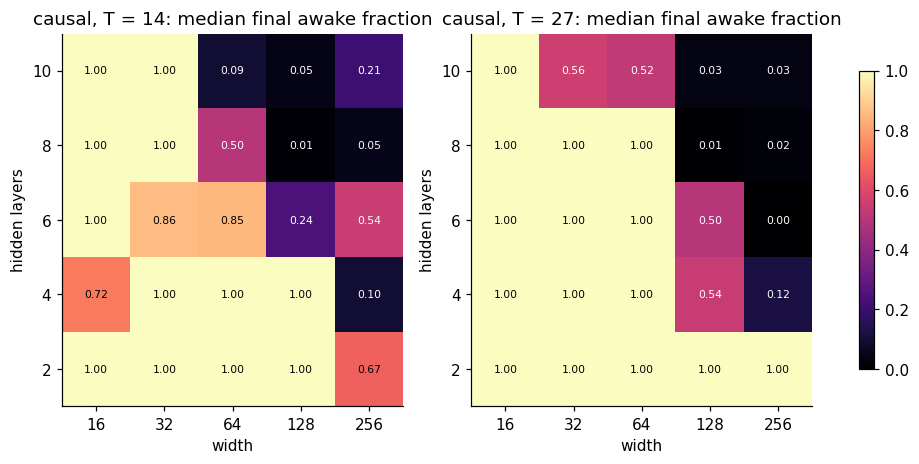

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for j, T in enumerate(cap.HORIZONS):
    ax = axes[j]
    sub = (df[(df.variant == "causal") & (df.horizon == T)]
           if len(df) else df)
    grid = np.full((len(cap.DEPTHS), len(cap.WIDTHS)), np.nan)
    if len(sub) and "final_awake_fraction" in sub:
        med = sub.groupby(["depth", "width"]).final_awake_fraction.median()
        for (d, w), v in med.items():
            grid[cap.DEPTHS.index(d), cap.WIDTHS.index(w)] = v
    im = ax.imshow(grid, cmap="magma", aspect="auto", vmin=0, vmax=1,
                   origin="lower")
    for a in range(len(cap.DEPTHS)):
        for b in range(len(cap.WIDTHS)):
            if np.isfinite(grid[a, b]):
                ax.text(b, a, f"{grid[a,b]:.2f}", ha="center", va="center",
                        fontsize=7, color="w" if grid[a, b] < 0.6 else "k")
    ax.set_xticks(range(len(cap.WIDTHS)), cap.WIDTHS)
    ax.set_yticks(range(len(cap.DEPTHS)), cap.DEPTHS)
    ax.set_xlabel("width")
    ax.set_ylabel("hidden layers")
    ax.set_title(f"causal, T = {T:g}: median final awake fraction")
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8)
fig.savefig(FIGURES / "04_front_vs_capacity.png", bbox_inches="tight")
plt.show()

## Figure 5 — the starting states

Relative L2 by starting state (all architectures overlaid) per (variant, horizon). The five
Latin-Hypercube starts include off-loop points whose trajectories begin with a transient
spiral onto the loop — if some starts are systematically harder, it shows here and matters
for how the earlier single-start studies generalise.

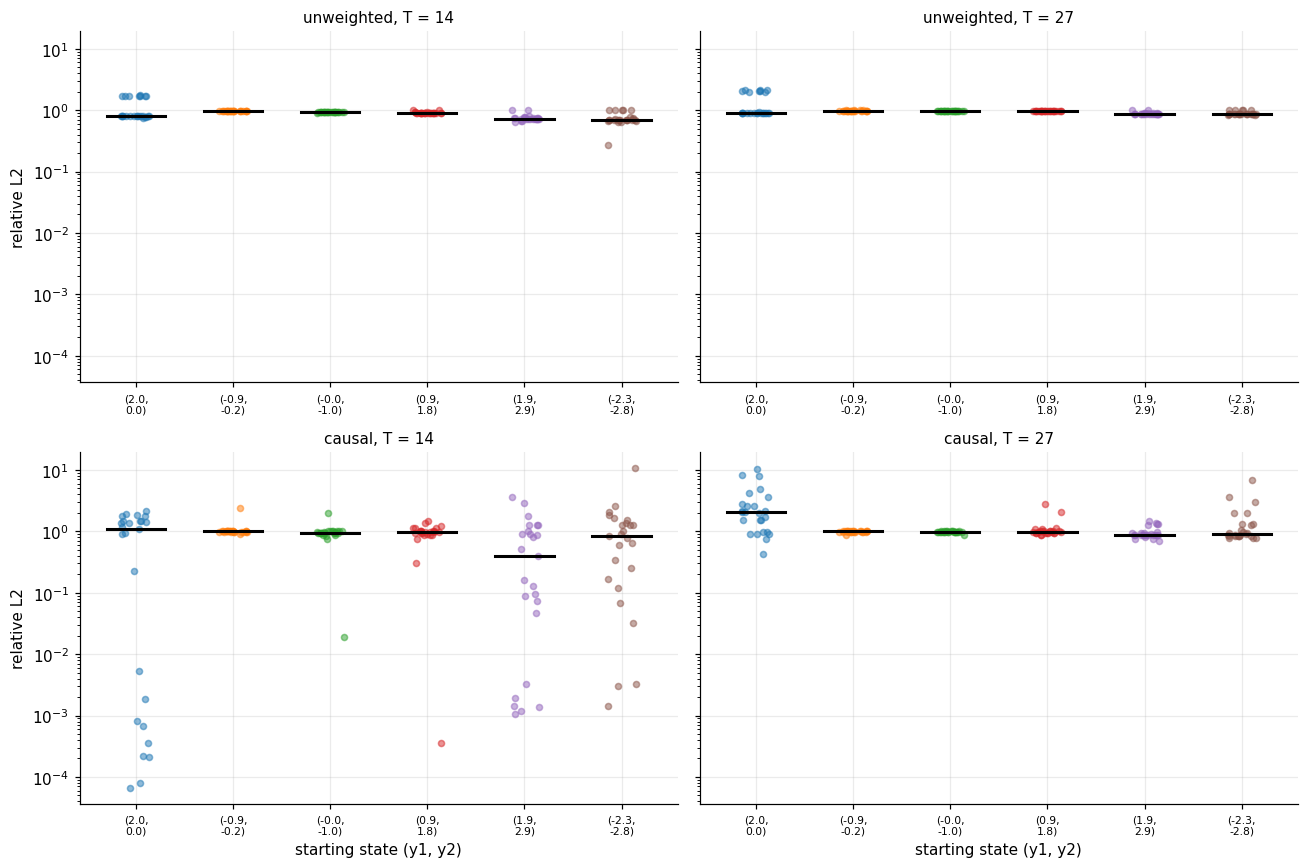

In [6]:
S = cap.starts()
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for i, variant in enumerate(cap.VARIANTS):
    for j, T in enumerate(cap.HORIZONS):
        ax = axes[i, j]
        sub = df[(df.variant == variant) & (df.horizon == T)] if len(df) else df
        if len(sub):
            for s in range(len(S)):
                g = sub[sub.start_idx == s]
                ax.semilogy([s] * len(g) + np.random.default_rng(s).uniform(
                    -0.15, 0.15, len(g)), g.rel_l2, "o", ms=4, alpha=0.5)
                if len(g):
                    ax.plot([s - 0.3, s + 0.3], [g.rel_l2.median()] * 2,
                            "k-", lw=2)
        labels = [f"({y1:.1f},\n{y2:.1f})" for y1, y2 in S]
        ax.set_xticks(range(len(S)), labels, fontsize=7)
        ax.set_title(f"{variant}, T = {T:g}", fontsize=10)
axes[0, 0].set_ylabel("relative L2")
axes[1, 0].set_ylabel("relative L2")
axes[1, 0].set_xlabel("starting state (y1, y2)")
axes[1, 1].set_xlabel("starting state (y1, y2)")
fig.tight_layout()
fig.savefig(FIGURES / "05_error_by_start.png", bbox_inches="tight")
plt.show()

## Summary tables

In [7]:
if len(df):
    print("median relative L2, depth x width, per (variant, horizon):")
    for (variant, T), sub in df.groupby(["variant", "horizon"]):
        print(f"\n== {variant}, T = {T:g}  ({len(sub)} runs) ==")
        print(sub.pivot_table(index="depth", columns="width",
                              values="rel_l2", aggfunc="median")
              .to_string(float_format=lambda v: f"{v:.2e}"))
    print("\nmedian rho MSE (state-modulus relative error):")
    print(df.groupby(["variant", "horizon"]).rho_mse.median()
          .to_string(float_format=lambda v: f"{v:.2e}"))
else:
    print("no completed runs yet")

median relative L2, depth x width, per (variant, horizon):

== causal, T = 14  (150 runs) ==
width      16       32       64       128      256
depth                                             
2     7.50e-01 5.50e-01 1.51e-01 4.89e-01 3.76e-01
4     1.16e+00 9.71e-01 5.09e-01 8.95e-01 1.19e+00
6     6.99e-01 8.62e-01 9.75e-01 7.84e-01 9.17e-01
8     9.78e-01 9.47e-01 9.74e-01 1.06e+00 1.15e+00
10    9.88e-01 9.67e-01 9.98e-01 1.20e+00 1.20e+00

== causal, T = 27  (150 runs) ==
width      16       32       64       128      256
depth                                             
2     9.61e-01 9.28e-01 9.28e-01 9.61e-01 9.71e-01
4     9.77e-01 9.93e-01 8.57e-01 1.00e+00 9.31e-01
6     8.77e-01 1.00e+00 9.40e-01 9.96e-01 9.92e-01
8     1.00e+00 9.87e-01 9.92e-01 9.92e-01 1.20e+00
10    1.00e+00 9.77e-01 1.02e+00 1.18e+00 1.22e+00

== unweighted, T = 14  (150 runs) ==
width      16       32       64       128      256
depth                                             
2     8.54e-01 8.51

## Conclusions

*(to be written once the sweep lands — and the follow-up, how the earlier horizon-sweep
analyses should be redone in light of these results, is to be discussed with George
first.)*